# Automatic Game Balancing with Top Trumps

Install required packages:

In [ ]:
%pip install numpy pymoo

## Top Trumps Implementation

In [2]:
import random
import numpy as np

class TopTrumpsSimulation:
    """TopTrumpsSimulation implements the basic TopTrumps game engine and agent-based simulation."""

    def __init__(self, num_cards=52, num_categories=6):
        self.K = num_cards  # Number of cards
        self.L = num_categories  # Number of categories

        self.set_random_deck()

    def _normalize_deck(self, deck):
        """Normalizes the deck such that each property is in the range [0,1]. This is required for the p0 agent."""
        min_values = [0] * self.L
        max_values = [0] * self.L

        for cat in range(self.L):
            all_values = [card[cat] for card in deck]
            min_values[cat] = min(all_values)
            max_values[cat] = max(all_values)

        normalized_deck = []

        for card in deck:
            normalized_card = [0] * self.L
            for cat in range(self.L):
                normalized_card[cat] = (card[cat] - min_values[cat]) / (max_values[cat] - min_values[cat])
            normalized_deck.append(normalized_card)

        return normalized_deck

    def set_deck(self, deck_list):
        """Creates a deck from deck_list of length K*L."""

        assert len(deck_list) == self.K * self.L

        deck = np.array_split(deck_list, self.K)

        self.deck = deck
        self._normalized_deck = self._normalize_deck(deck)

    def set_random_deck(self, value_range = (1, 10)):
        """Generates a random deck with values in value_range."""
        deck_list = np.random.uniform(value_range[0], value_range[1], self.K * self.L)
        self.set_deck(deck_list)

    def get_p0_choice(self, card):
        """p0 assumes uniform distribution between max and min values per property and then picks the best value on current card."""
        return card.index(max(card))

    def get_p4_choice(self, card, remaining_cards):
        """p4 calculates exact win probability based on remaining cards."""
        best_prob = -1
        best_cat = 0

        for cat_idx in range(self.L):
            my_val = card[cat_idx]
            # Count how many cards in the potential card pool have a lower value
            wins = sum(1 for opp_card in remaining_cards if my_val > opp_card[cat_idx])
            prob = wins / len(remaining_cards)

            if prob > best_prob:
                best_prob = prob
                best_cat = cat_idx
        # print(f"Best prob: {best_prob:.2f}, cat: {best_cat}")
        return best_cat

    def simulate_game(self):
        # Shuffle and distribute cards
        temp_deck = list(self._normalized_deck)
        random.shuffle(temp_deck)

        # p4 vs p0 setup
        p4_hand = temp_deck[:self.K//2]
        p0_hand = temp_deck[self.K//2:]

        # Track unplayed cards remaining in the 'unplayed' pool for p4's knowledge 
        all_unplayed = list(temp_deck) 

        p4_tricks = 0
        current_turn = random.choice(['p4', 'p0']) # Random starting player
        trick_changes = 0

        # Game ends after all cards played once
        for i in range(self.K // 2):
            card_p4 = p4_hand[i]
            card_p0 = p0_hand[i]

            # Category Selection
            if current_turn == 'p4':
                category = self.get_p4_choice(card_p4, all_unplayed)
            else:
                category = self.get_p0_choice(card_p0)

            # Determine Round Winner
            val_p4 = card_p4[category]
            val_p0 = card_p0[category]

            # Remove current p0, p4 card from p4's tracking memory
            all_unplayed.remove(card_p0)
            all_unplayed.remove(card_p4)

            if val_p4 > val_p0:
                # print("P4 wins!")
                p4_tricks += 1
                if current_turn == 'p0':
                    current_turn = 'p4'
                    trick_changes += 1
            elif val_p0 > val_p4:
                # print("P0 wins!")
                if current_turn == 'p4':
                    current_turn = 'p0'
                    trick_changes += 1
            # In case of draw, current player keeps the lead

        return {
            "p4_tricks": p4_tricks,
            "trick_changes": trick_changes,
            "p4_won": p4_tricks > (self.K / 4) # p4 wins if they got more than half the tricks
        }

Test implementation on a random deck:

In [3]:
num_cards = 22
num_categories = 4
num_repetitions = 1000

sim = TopTrumpsSimulation(num_cards=num_cards, num_categories=num_categories)
sim.set_deck(np.random.uniform(0, 10, num_cards * num_categories))
results = [sim.simulate_game() for _ in range(num_repetitions)]

avg_p4_win_rate = sum(1 for r in results if r['p4_won']) / num_repetitions
avg_tricks = sum(r['p4_tricks'] for r in results) / num_repetitions
avg_trick_changes = sum(r['trick_changes'] for r in results) / num_repetitions

print(f"Results over {num_repetitions} runs:")
print(f"p4 Win Rate: {avg_p4_win_rate:.2%}")
print(f"Average p4 Tricks: {avg_tricks:.2f}")
print(f"Average Trick Changes: {avg_trick_changes:.2f}")

Results over 1000 runs:
p4 Win Rate: 57.10%
Average p4 Tricks: 6.08
Average Trick Changes: 1.60


## Pymoo connection

TopTrumpsBalancing provides a pymoo-compatible interface for TopTrumpsSimulation. Note that the objectives are already negated to result in a minimization problem!

In [4]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem

class TopTrumpsBalancing(ElementwiseProblem):
    """TopTrumpsBalancing connects TopTrumpsSimulation with the pymoo interface ElementwiseProblem."""

    def __init__(self, sim_instance, n_simulations=100):
        self.sim = sim_instance
        self.n_simulations = n_simulations
        
        # KL variables: Number of cards (K) * Categories (L) 
        n_var = self.sim.K * self.sim.L
        
        super().__init__(n_var=n_var,
                         n_obj=2, # Objectives: Fairness (p4 win rate) and Excitement (# trick changes)
                         n_constr=0,
                         xl=0.0, # Lower bound for values
                         xu=1.0) # Upper bound for values

    def _evaluate(self, x, out, *args, **kwargs):
        # Update simulation with the current candidate deck
        self.sim.set_deck(x)
        
        win_rates = []
        trick_changes_list = []
        
        # Perform multiple simulations to get an average
        for _ in range(self.n_simulations):
            res = self.sim.simulate_game()
            win_rates.append(1 if res['p4_won'] else 0)
            trick_changes_list.append(res['trick_changes'])
        
        # Objectives (Minimization):
        # f1: -Average Win Rate of p4 (Fairness)
        # f2: -Average Trick Changes (Excitement)
        out["F"] = [
            -np.mean(win_rates), 
            -np.mean(trick_changes_list)
        ]

Set up simulation and problem instance:

In [5]:
my_sim = TopTrumpsSimulation(num_cards=22, num_categories=4)
problem = TopTrumpsBalancing(my_sim, n_simulations=1000)

Now it's your turn: Optimize `problem` using an approach of your choice and analyze the results. Please refer to the documentation of [pymoo](https://pymoo.org) for more details. A good starting point is: <https://pymoo.org/getting_started/part_2.html#Initialize-an-Algorithm>

In [6]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

algorithm = NSGA2(
    pop_size=40,
    n_offsprings=10,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

In [7]:
from pymoo.termination import get_termination

termination = get_termination("n_gen", 200)

In [8]:
from pymoo.optimize import minimize

res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)

X = res.X
F = res.F

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       40 |      4 |             - |             -
     2 |       50 |      4 |  0.000000E+00 |             f
     3 |       60 |      4 |  0.000000E+00 |             f
     4 |       70 |      4 |  0.000000E+00 |             f
     5 |       80 |      6 |  0.0948947883 |             f
     6 |       90 |      6 |  0.000000E+00 |             f
     7 |      100 |      6 |  0.000000E+00 |             f
     8 |      110 |      5 |  0.0505107009 |             f
     9 |      120 |      3 |  0.5188679245 |         ideal
    10 |      130 |      3 |  0.000000E+00 |             f
    11 |      140 |      3 |  0.000000E+00 |             f
    12 |      150 |      3 |  0.000000E+00 |             f
    13 |      160 |      3 |  0.000000E+00 |             f
    14 |      170 |      3 |  0.000000E+00 |             f
    15 |      180 |      2 |  0.3296460177 |         ideal
    16 |      190 |      2 |  0.000000E+00 |            

In [13]:
res.algorithm

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

def visualize_deck_rank_variance(deck, K, L):
    """
    Converts deck values to ranks per category, calculates within-card rank variance,
    and visualizes cards based on their rank characteristics.
    
    Parameters:
    -----------
    deck : array-like
        Flat array of length K*L containing all card values
    K : int
        Number of cards
    L : int
        Number of categories
    """
    # Reshape deck into (K cards, L categories)
    deck_array = np.array(deck).reshape(K, L)
    
    # Calculate ranks for each category (column-wise)
    # rankdata with method='average' handles ties by giving them average rank
    ranked_deck = np.zeros_like(deck_array)
    for cat in range(L):
        ranked_deck[:, cat] = rankdata(deck_array[:, cat], method='average')
    
    # Calculate within-card rank variance for each card
    card_rank_variance = np.var(ranked_deck, axis=1)
    
    # Calculate mean rank for each card (indicates overall card strength)
    card_mean_rank = np.mean(ranked_deck, axis=1)
    
    # Calculate rank range for each card (max - min rank)
    card_rank_range = np.max(ranked_deck, axis=1) - np.min(ranked_deck, axis=1)
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Scatter - Mean Rank vs Rank Variance (FIXED AXES)
    ax1 = axes[0]
    scatter = ax1.scatter(card_mean_rank, card_rank_variance, 
                         c=card_rank_range, cmap='viridis', 
                         s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax1.set_xlabel('Mean Rank (Card Strength)', fontsize=11)
    ax1.set_ylabel('Rank Variance (Specialization)', fontsize=11)
    ax1.set_title('Card Characteristics: Strength vs Specialization', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # FIXED AXES for scatter plot
    ax1.set_xlim(0.5, K + 0.5)
    # Maximum possible variance for ranks 1 to K: when ranks are [1, 1, ..., K, K]
    max_possible_variance = np.var([1] * (L//2) + [K] * (L - L//2))
    ax1.set_ylim(-0.5, max_possible_variance + 5)
    
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Rank Range', fontsize=10)
    
    # Add quadrant labels
    mid_rank = (K + 1) / 2
    mid_var = max_possible_variance / 2
    ax1.axhline(mid_var, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax1.axvline(mid_rank, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax1.text(mid_rank * 0.5, ax1.get_ylim()[1] * 0.95, 'Weak\nSpecialists', 
             ha='center', va='top', fontsize=9, alpha=0.6)
    ax1.text(mid_rank * 1.5, ax1.get_ylim()[1] * 0.95, 'Strong\nSpecialists', 
             ha='center', va='top', fontsize=9, alpha=0.6)
    ax1.text(mid_rank * 0.5, ax1.get_ylim()[1] * 0.05, 'Weak\nGeneralists', 
             ha='center', va='bottom', fontsize=9, alpha=0.6)
    ax1.text(mid_rank * 1.5, ax1.get_ylim()[1] * 0.05, 'Strong\nGeneralists', 
             ha='center', va='bottom', fontsize=9, alpha=0.6)
    
    # Plot 2: Boxplot of rank variances (FIXED AXES)
    ax2 = axes[1]
    bp = ax2.boxplot([card_rank_variance], 
                     labels=['Rank Variance'],
                     patch_artist=True,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', 
                                  markeredgecolor='red', markersize=8),
                     vert=True)
    
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Rank Variance (Specialization)', fontsize=11)
    ax2.set_title('Distribution of Card Specialization', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # FIXED AXES for boxplot
    ax2.set_ylim(-0.5, max_possible_variance + 5)
    
    # Add horizontal reference lines
    ax2.axhline(np.mean(card_rank_variance), color='red', 
                linestyle='--', linewidth=1.5, alpha=0.7, label=f'Mean: {np.mean(card_rank_variance):.2f}')
    ax2.axhline(np.median(card_rank_variance), color='orange', 
                linestyle='--', linewidth=1.5, alpha=0.7, label=f'Median: {np.median(card_rank_variance):.2f}')
    ax2.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    
    
    return ranked_deck, card_rank_variance

# Example usage:
# ranked_deck, variances = visualize_deck_rank_variance(res.X[0], problem.sim.K, problem.sim.L)

/tmp/ipykernel_277806/3324882063.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(category_data,


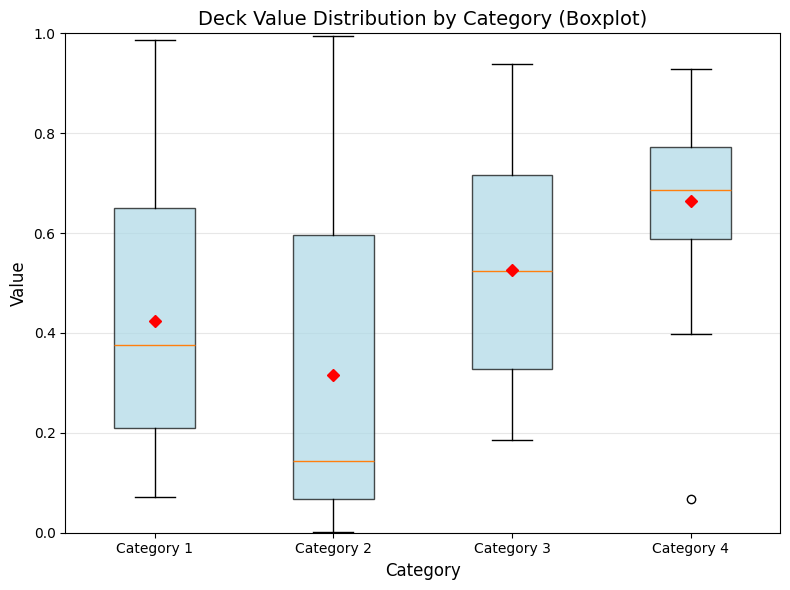

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_deck_boxplot(deck, K, L):
    """
    Visualizes the distribution of card values for each category using boxplots.
    
    Parameters:
    -----------
    deck : array-like
        Flat array of length K*L containing all card values
    K : int
        Number of cards
    L : int
        Number of categories
    """
    # Reshape deck into (K cards, L categories)
    deck_array = np.array(deck).reshape(K, L)
    
    # Prepare data for boxplot - list of arrays, one per category
    category_data = [deck_array[:, cat] for cat in range(L)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(max(8, L * 1.5), 6))
    
    # Create boxplot
    bp = ax.boxplot(category_data, 
                    labels=[f'Category {i+1}' for i in range(L)],
                    patch_artist=True,
                    showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='red', 
                                  markeredgecolor='red', markersize=6))
    
    # Customize boxplot colors
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    # Styling
    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title('Deck Value Distribution by Category (Boxplot)', fontsize=14)
    ax.set_ylim(0, 1)  # Since values are between 0-1
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
visualize_deck_boxplot(res.X[0], problem.sim.K, problem.sim.L)

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_deck(deck, K, L):
    """
    Visualizes the distribution of card values for each category.
    
    Parameters:
    -----------
    deck : array-like
        Flat array of length K*L containing all card values
    K : int
        Number of cards
    L : int
        Number of categories
    """
    # Reshape deck into (K cards, L categories)
    deck_array = np.array(deck).reshape(K, L)
    
    # Create subplots - one histogram per category
    fig, axes = plt.subplots(2, (L + 1) // 2, figsize=(12, 6))
    axes = axes.flatten() if L > 1 else [axes]
    
    for cat in range(L):
        # Extract all values for this category across all cards
        category_values = deck_array[:, cat]
        
        # Plot histogram
        axes[cat].hist(category_values, bins=10, edgecolor='black', alpha=0.7)
        axes[cat].set_title(f'Category {cat + 1}')
        axes[cat].set_xlabel('Value')
        axes[cat].set_ylabel('Frequency')
        axes[cat].set_xlim(0, 1)  # Since values are between 1-10
        axes[cat].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(L, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Deck Value Distribution by Category', y=1.02, fontsize=14)
    plt.show()

# Example usage with your optimization results:
# Visualize the first Pareto-optimal solution
#visualize_deck(res.X[0], problem.sim.K, problem.sim.L)

Best Fairness Solution:
  Objective 1 (Fairness): -0.7790
  Objective 2 (Excitement): -3.4190



/tmp/ipykernel_277806/534433633.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([card_rank_variance],


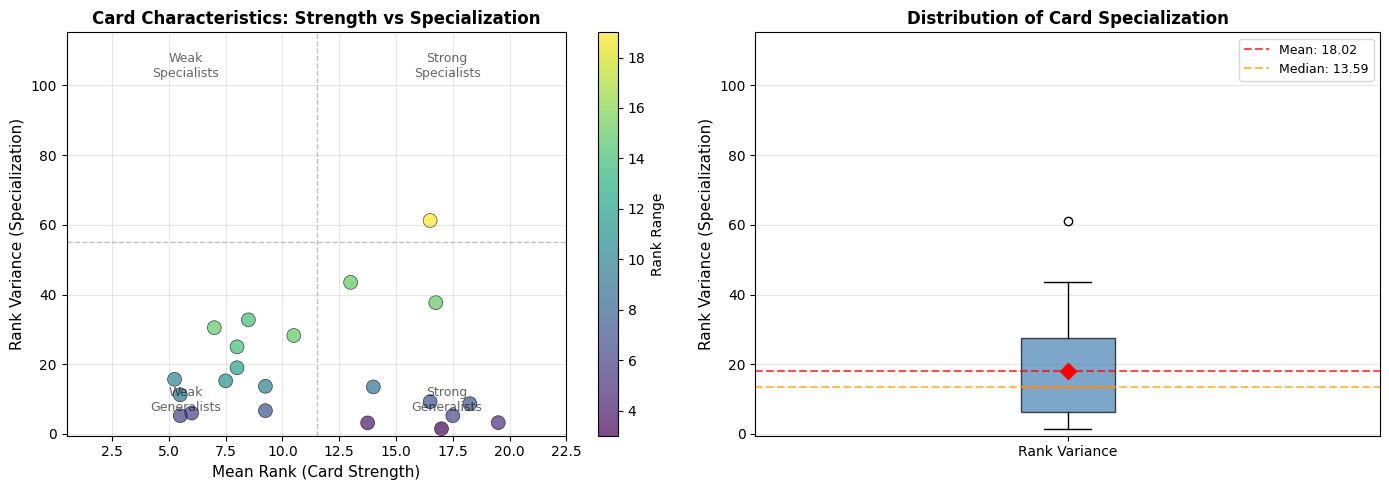

Best Excitement Solution:
  Objective 1 (Fairness): -0.6920
  Objective 2 (Excitement): -3.8000



/tmp/ipykernel_277806/534433633.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([card_rank_variance],


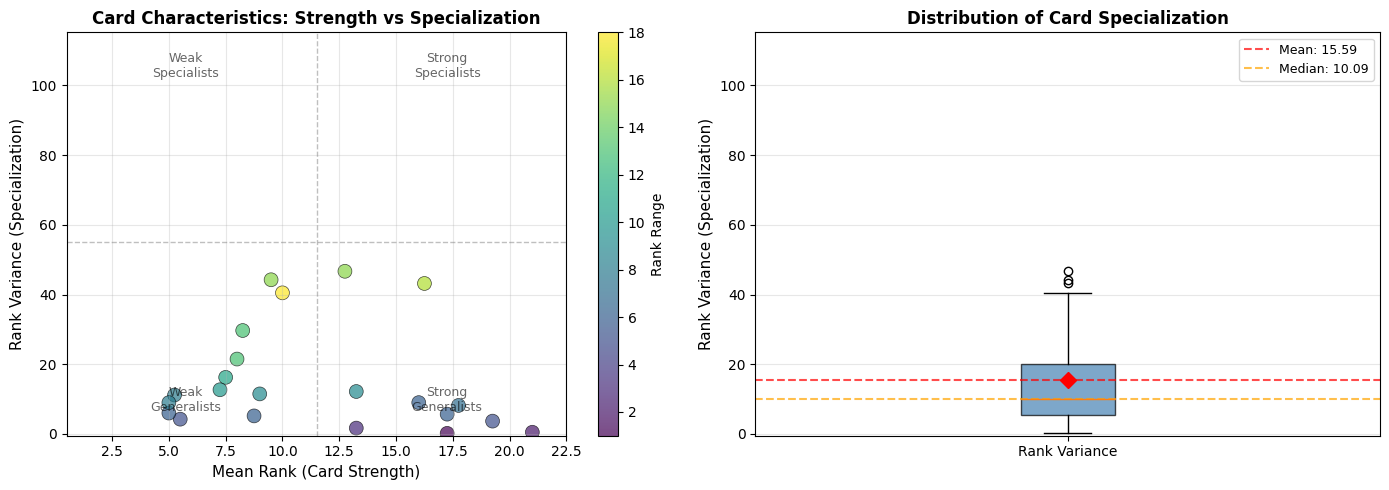

(array([[ 7.,  7.,  2.,  6.],
        [15.,  9., 11., 18.],
        [21., 22., 21., 20.],
        [12.,  8.,  1.,  9.],
        [ 3.,  5.,  9.,  3.],
        [22.,  6., 22., 15.],
        [ 2., 12.,  7.,  8.],
        [ 5., 16., 16.,  1.],
        [ 9., 11.,  5., 10.],
        [14., 15., 12., 12.],
        [18., 20., 17., 22.],
        [11.,  3.,  3.,  4.],
        [19., 13., 19., 13.],
        [13.,  4.,  8., 11.],
        [17., 17., 18., 17.],
        [ 4., 10.,  4.,  2.],
        [10.,  1., 10., 19.],
        [ 1., 14., 13.,  5.],
        [ 6., 18.,  6., 21.],
        [20., 21., 14., 16.],
        [16., 19., 20., 14.],
        [ 8.,  2., 15.,  7.]]),
 array([ 4.25  , 12.1875,  0.5   , 16.25  ,  6.    , 43.1875, 12.6875,
        44.25  ,  5.1875,  1.6875,  3.6875, 11.1875,  9.    , 11.5   ,
         0.1875,  9.    , 40.5   , 29.6875, 46.6875,  8.1875,  5.6875,
        21.5   ]))

In [38]:
# Best solution for Objective 1 (Fairness - most negative = best)
best_obj1_idx = np.argmin(F[:, 0])
best_fairness_deck = X[best_obj1_idx]
best_fairness_score = F[best_obj1_idx]

print(f"Best Fairness Solution:")
print(f"  Objective 1 (Fairness): {best_fairness_score[0]:.4f}")
print(f"  Objective 2 (Excitement): {best_fairness_score[1]:.4f}")
print()

#visualize_deck(best_fairness_deck, problem.sim.K, problem.sim.L)
visualize_deck_rank_variance(best_fairness_deck, problem.sim.K, problem.sim.L)

# Best solution for Objective 2 (Excitement - most negative = best)
best_obj2_idx = np.argmin(F[:, 1])
best_excitement_deck = X[best_obj2_idx]
best_excitement_score = F[best_obj2_idx]

print(f"Best Excitement Solution:")
print(f"  Objective 1 (Fairness): {best_excitement_score[0]:.4f}")
print(f"  Objective 2 (Excitement): {best_excitement_score[1]:.4f}")
print()

#visualize_deck(best_excitement_deck, problem.sim.K, problem.sim.L)
visualize_deck_rank_variance(best_excitement_deck, problem.sim.K, problem.sim.L)

In [25]:
best_excitement_deck == best_fairness_deck

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False,  True, False, False, False, False,  True, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False,  True, False, False, False, False,  True,
       False, False, False, False, False,  True, False, False, False,
       False, False,  True, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False,  True, False, False, False])

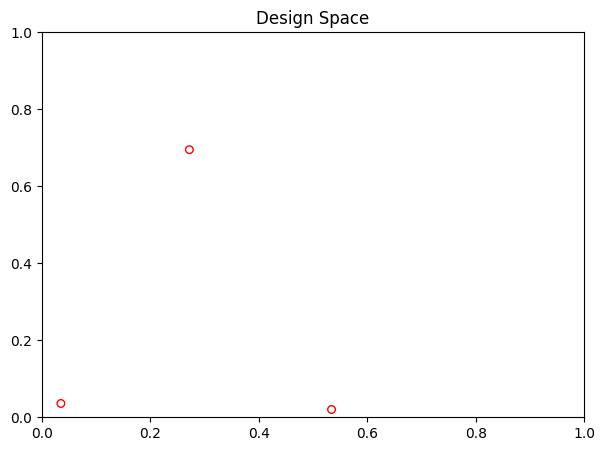

In [37]:
import matplotlib.pyplot as plt
xl, xu = problem.bounds()
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, facecolors='none', edgecolors='r')
plt.xlim(xl[0], xu[0])
plt.ylim(xl[1], xu[1])
plt.title("Design Space")
plt.show()

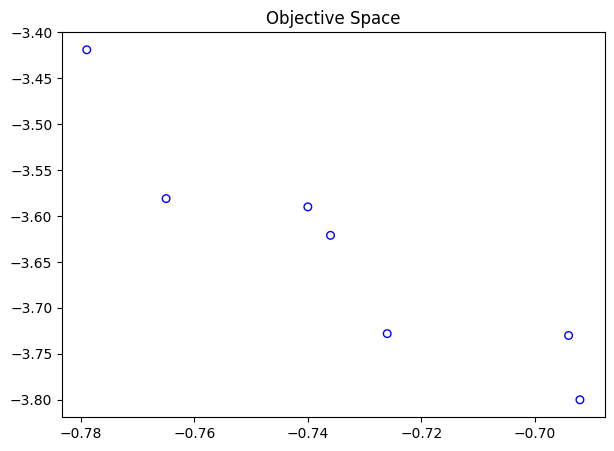

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 0], F[:, 1], s=30, facecolors='none', edgecolors='blue')
plt.title("Objective Space")
plt.show()

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

def visualize_objective_space_with_variance(X, F, K, L):
    """
    Visualizes the objective space (Fairness vs Excitement) with decks colored by mean rank variance.
    
    Parameters:
    -----------
    X : array-like
        Array of shape (n_decks, K*L) containing all deck configurations
    F : array-like
        Array of shape (n_decks, 2) containing objective values [fairness, excitement]
    K : int
        Number of cards
    L : int
        Number of categories
    """
    
    def calculate_mean_rank_variance(deck):
        """Calculate the mean rank variance for a given deck."""
        # Reshape deck into (K cards, L categories)
        deck_array = np.array(deck).reshape(K, L)
        
        # Calculate ranks for each category (column-wise)
        ranked_deck = np.zeros_like(deck_array)
        for cat in range(L):
            ranked_deck[:, cat] = rankdata(deck_array[:, cat], method='average')
        
        # Calculate within-card rank variance for each card
        card_rank_variance = np.var(ranked_deck, axis=1)
        
        # Return mean variance across all cards
        return np.mean(card_rank_variance)
    
    # Calculate mean rank variance for all decks
    mean_rank_variances = np.array([calculate_mean_rank_variance(X[i]) for i in range(len(X))])
    
    # Create the plot
    plt.figure(figsize=(9, 6))
    scatter = plt.scatter(-F[:, 0], -F[:, 1], c=mean_rank_variances, 
                         s=80, cmap='viridis', edgecolors='black', linewidth=0.5, alpha=0.8)
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Mean Within-Card Rank Variance', fontsize=11)
    
    plt.xlabel('Fairness', fontsize=11)
    plt.ylabel('Excitement', fontsize=11)
    plt.title(f"Mean Within-Card Rank Variance Influence on Optimization Objectives", 
          fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
 
    
    return mean_rank_variances

# Example usage:
# mean_variances = visualize_objective_space_with_variance(X, F, K=22, L=4)

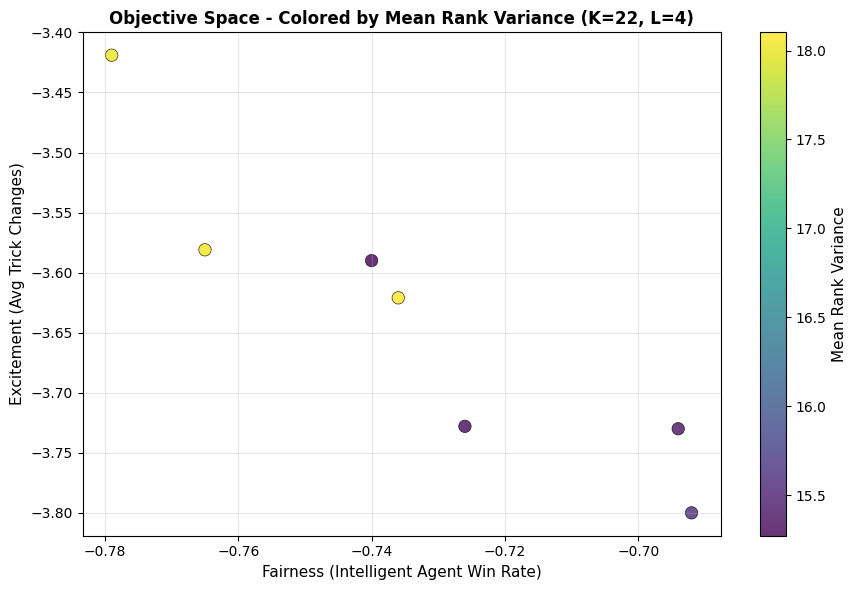

CORRELATION ANALYSIS
Number of decks analyzed: 7
K (cards): 22, L (categories): 4

Mean Rank Variance Statistics:
  Min:  15.273
  Max:  18.102
  Mean: 16.537
  Std:  1.319

Correlations:
  Mean Rank Variance ↔ Fairness:   -0.729
  Mean Rank Variance ↔ Excitement: +0.685
  Fairness ↔ Excitement:            -0.927


array([18.10227273, 18.01704545, 18.05113636, 15.39204545, 15.33522727,
       15.27272727, 15.59090909])

In [42]:
visualize_objective_space_with_variance(X,F,problem.sim.K,problem.sim.L)

In [43]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS

algorithm = NSGA2(
    pop_size=100,  # Increased from 40
    n_offsprings=50,  # Increased from 10
    sampling=LHS(),  # Better initial distribution
    crossover=SBX(prob=0.9, eta=10),  # Lower eta for more exploration
    mutation=PM(eta=15, prob=1.0/problem.n_var),  # More explorative mutation
    eliminate_duplicates=True
)

termination = get_termination("n_gen", 300)  # More generations

res = minimize(problem,
               algorithm,
               termination,
               seed=1,
               save_history=True,
               verbose=True)
X=res.X
F=res.F

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      3 |             - |             -
     2 |      150 |      4 |  0.0441176471 |         ideal
     3 |      200 |      4 |  0.2125000000 |         ideal
     4 |      250 |      4 |  0.000000E+00 |             f
     5 |      300 |      5 |  0.0482343125 |             f
     6 |      350 |      6 |  0.0538897065 |             f
     7 |      400 |      5 |  0.0816000000 |         ideal
     8 |      450 |      3 |  0.0714285714 |         ideal
     9 |      500 |      3 |  0.000000E+00 |             f
    10 |      550 |      6 |  0.1361123791 |             f
    11 |      600 |      8 |  0.1572700297 |         ideal
    12 |      650 |      4 |  0.0594800050 |             f
    13 |      700 |      4 |  0.5415019763 |         ideal
    14 |      750 |      5 |  0.5040000000 |         ideal
    15 |      800 |      7 |  0.0417286008 |             f
    16 |      850 |      7 |  0.0656682813 |            

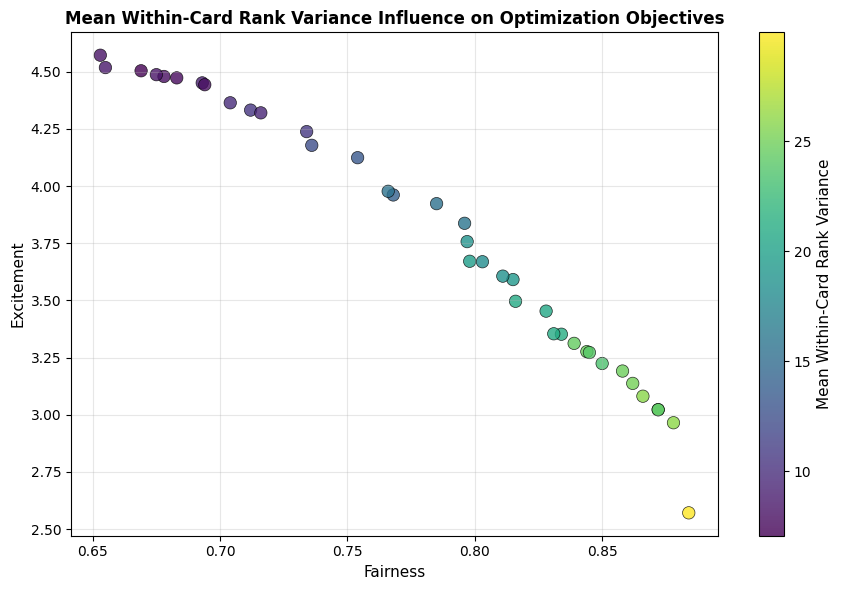

array([19.71590909, 20.90340909, 24.76136364,  8.97727273, 21.06818182,
       12.36931818, 24.41477273, 18.63068182, 24.67045455,  7.51136364,
       23.34090909, 19.25568182, 13.31818182,  8.55681818, 13.94886364,
        7.82954545, 25.9375    , 24.07954545,  7.0625    , 15.64772727,
       20.98863636,  8.26704545, 10.56818182,  7.94318182, 15.50568182,
       25.11363636,  9.43181818, 18.06818182,  8.21590909, 10.65340909,
       24.8125    , 29.94318182,  9.80681818, 20.6875    , 15.90909091,
       23.9375    , 25.83522727, 18.58522727])

In [52]:
visualize_objective_space_with_variance(X,F,problem.sim.K,problem.sim.L)

Best Fairness Solution:
  Objective 1 (Fairness): -0.8840
  Objective 2 (Excitement): -2.5710



/tmp/ipykernel_277806/534433633.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([card_rank_variance],


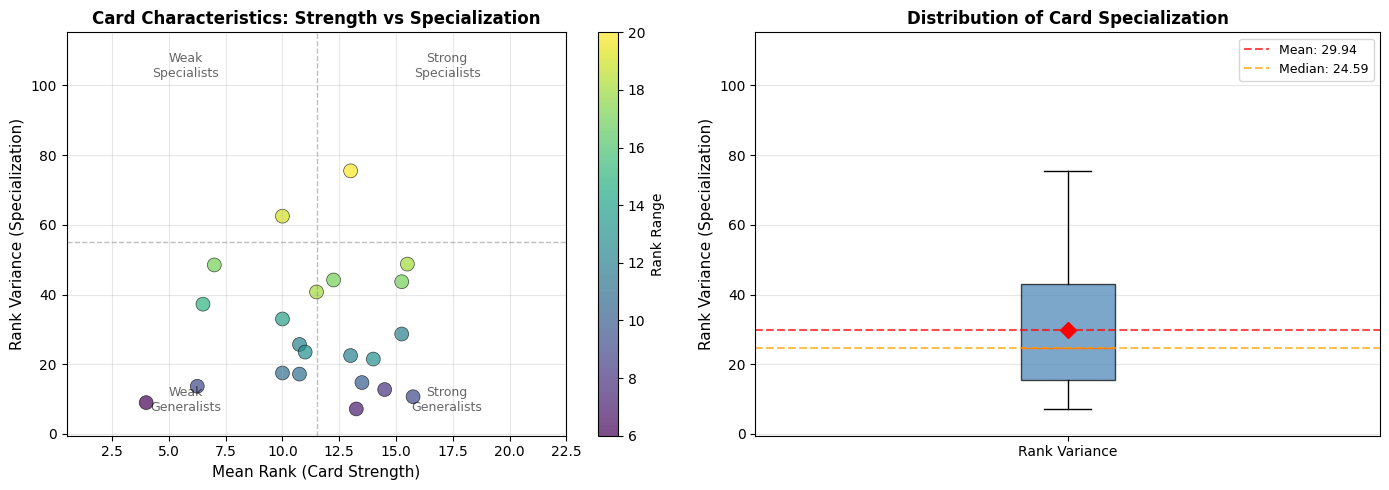

Best Excitement Solution:
  Objective 1 (Fairness): -0.6530
  Objective 2 (Excitement): -4.5720



/tmp/ipykernel_277806/534433633.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([card_rank_variance],


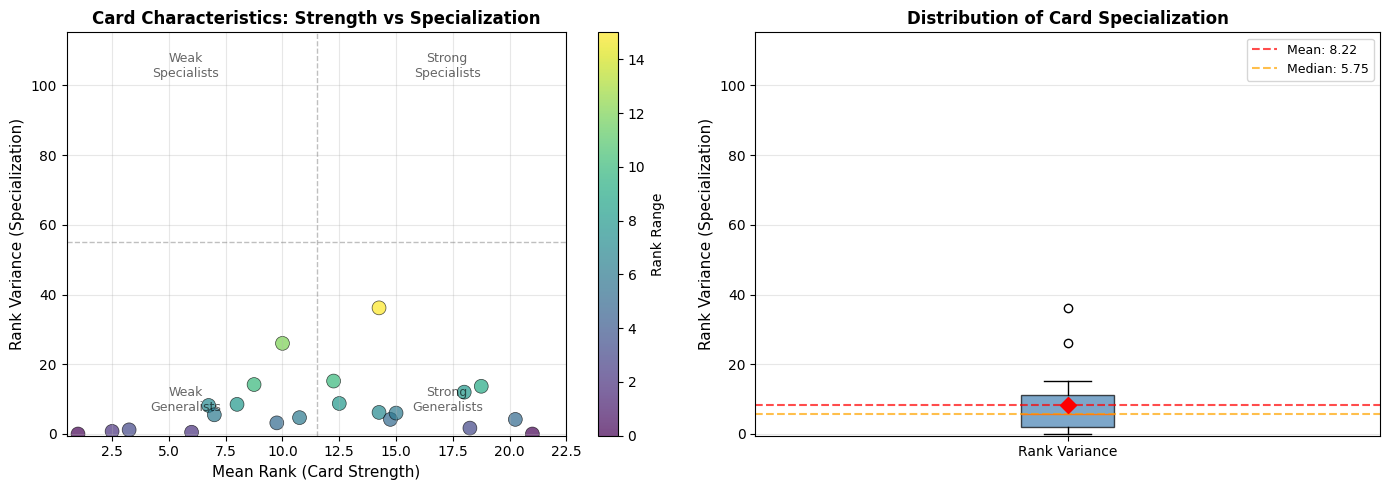

(array([[10.,  9.,  3.,  5.],
        [ 2.,  2.,  4.,  2.],
        [ 4., 14.,  6., 16.],
        [17., 11.,  9., 13.],
        [14., 18., 14., 11.],
        [18., 22., 13., 22.],
        [21., 21., 21., 21.],
        [13., 13., 15., 18.],
        [12.,  6., 16., 15.],
        [ 3.,  8.,  8.,  9.],
        [ 6.,  7.,  5.,  6.],
        [22., 17., 22., 20.],
        [ 7., 12., 10., 10.],
        [ 8., 10., 11., 14.],
        [20., 20., 20., 12.],
        [15.,  5.,  7.,  8.],
        [ 9.,  4., 12.,  7.],
        [ 5.,  3.,  2.,  3.],
        [ 1.,  1.,  1.,  1.],
        [11., 15., 17., 17.],
        [16., 19., 19., 19.],
        [19., 16., 18.,  4.]]),
 array([ 8.1875,  0.75  , 26.    ,  8.75  ,  6.1875, 13.6875,  0.    ,
         4.1875, 15.1875,  5.5   ,  0.5   ,  4.1875,  3.1875,  4.6875,
        12.    , 14.1875,  8.5   ,  1.1875,  0.    ,  6.    ,  1.6875,
        36.1875]))

In [53]:
# Best solution for Objective 1 (Fairness - most negative = best)
best_obj1_idx = np.argmin(F[:, 0])
best_fairness_deck = X[best_obj1_idx]
best_fairness_score = F[best_obj1_idx]

print(f"Best Fairness Solution:")
print(f"  Objective 1 (Fairness): {best_fairness_score[0]:.4f}")
print(f"  Objective 2 (Excitement): {best_fairness_score[1]:.4f}")
print()

#visualize_deck(best_fairness_deck, problem.sim.K, problem.sim.L)
visualize_deck_rank_variance(best_fairness_deck, problem.sim.K, problem.sim.L)

# Best solution for Objective 2 (Excitement - most negative = best)
best_obj2_idx = np.argmin(F[:, 1])
best_excitement_deck = X[best_obj2_idx]
best_excitement_score = F[best_obj2_idx]

print(f"Best Excitement Solution:")
print(f"  Objective 1 (Fairness): {best_excitement_score[0]:.4f}")
print(f"  Objective 2 (Excitement): {best_excitement_score[1]:.4f}")
print()

#visualize_deck(best_excitement_deck, problem.sim.K, problem.sim.L)
visualize_deck_rank_variance(best_excitement_deck, problem.sim.K, problem.sim.L)

In [ ]:
print("fairness optimized")
visualize_deck(best_fairness_deck, problem.sim.K, problem.sim.L)
print("excitement optimized")
visualize_deck(best_excitement_deck, problem.sim.K, problem.sim.L)